Selected videos:
LEFT route video:  left_route.mp4
RIGHT route video: right_route.mp4
QUERY route video: query_route.mp4

✅ Frame extraction complete.
left_route: 120 frames from first 20.00 seconds
right_route: 120 frames from first 20.00 seconds
query_route: 120 frames from first 20.00 seconds


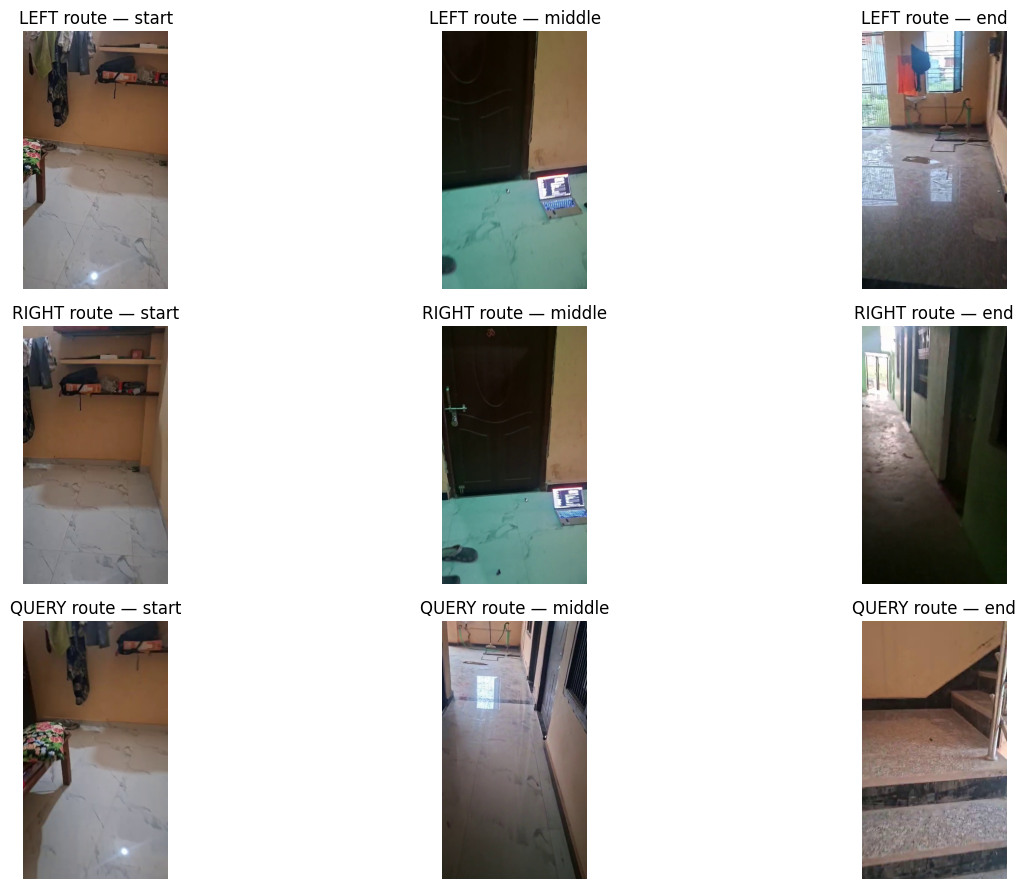

In [3]:
# ============================================================
# CELL 1: VIDEO FRAME EXTRACTION
# VXN-RAMNet Shared-Prefix Branch Graph Builder — DTW Version
#
# Video 1 = LEFT route after divergence
# Video 2 = RIGHT route after divergence
# Video 3 = Query route to classify
# ============================================================

import sys
import subprocess
from pathlib import Path
import shutil
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("opencv-python", "cv2")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("pillow", "PIL")
install_if_missing("matplotlib", "matplotlib")

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

ROOT_DIR = Path(".")
VIDEOS_DIR = ROOT_DIR / "videos"

# Change these names if your files are different
LEFT_ROUTE_VIDEO_NAME = "left_route.mp4"
RIGHT_ROUTE_VIDEO_NAME = "right_route.mp4"
QUERY_ROUTE_VIDEO_NAME = "query_route.mp4"

OUTPUT_DIR = ROOT_DIR / "vxn_branch_frames_dtw"

MAX_VIDEO_SECONDS = 20

# More frames = better synchronization.
# 120 frames from 20 seconds = about 6 sampled frames per second.
FRAMES_PER_VIDEO = 120

VIDEO_EXTENSIONS = [".mp4", ".mov", ".avi", ".mkv", ".webm"]


# ------------------------------------------------------------
# FIND VIDEO FILES
# ------------------------------------------------------------

def find_video(filename):
    candidates = [
        VIDEOS_DIR / filename,
        ROOT_DIR / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

left_video_path = find_video(LEFT_ROUTE_VIDEO_NAME)
right_video_path = find_video(RIGHT_ROUTE_VIDEO_NAME)
query_video_path = find_video(QUERY_ROUTE_VIDEO_NAME)

if left_video_path is None or right_video_path is None or query_video_path is None:
    print("Manual filenames not fully found. Trying auto-detect fallback...")

    search_dirs = []
    if VIDEOS_DIR.exists():
        search_dirs.append(VIDEOS_DIR)
    search_dirs.append(ROOT_DIR)

    all_videos = []
    for folder in search_dirs:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in VIDEO_EXTENSIONS:
                all_videos.append(file)

    all_videos = sorted(list(set(all_videos)))

    if len(all_videos) < 3:
        raise FileNotFoundError(
            "Need 3 videos:\n"
            "videos/left_route.mp4\n"
            "videos/right_route.mp4\n"
            "videos/query_route.mp4"
        )

    left_video_path = all_videos[0]
    right_video_path = all_videos[1]
    query_video_path = all_videos[2]

print("Selected videos:")
print("LEFT route video: ", left_video_path)
print("RIGHT route video:", right_video_path)
print("QUERY route video:", query_video_path)


# ------------------------------------------------------------
# PREPARE OUTPUT FOLDERS
# ------------------------------------------------------------

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

LEFT_FRAMES_DIR = OUTPUT_DIR / "left_route"
RIGHT_FRAMES_DIR = OUTPUT_DIR / "right_route"
QUERY_FRAMES_DIR = OUTPUT_DIR / "query_route"

LEFT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
RIGHT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
QUERY_FRAMES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# VIDEO HELPERS
# ------------------------------------------------------------

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    duration = total_frames / fps if fps > 0 else 0

    cap.release()

    return {
        "fps": fps,
        "total_frames": total_frames,
        "duration_seconds": duration
    }

def extract_evenly_spaced_frames(video_path, output_folder, frame_count=120, max_seconds=20):
    info = get_video_info(video_path)

    fps = info["fps"]
    total_frames = info["total_frames"]
    duration = info["duration_seconds"]

    usable_seconds = min(duration, max_seconds)
    usable_frame_count = int(usable_seconds * fps)
    usable_frame_count = min(usable_frame_count, total_frames)

    if usable_frame_count <= 0:
        raise ValueError(f"No usable frames in video: {video_path}")

    frame_indices = np.linspace(
        0,
        max(0, usable_frame_count - 1),
        frame_count,
        dtype=int
    )

    cap = cv2.VideoCapture(str(video_path))

    saved_paths = []

    for out_idx, frame_idx in enumerate(frame_indices, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success:
            print(f"Warning: could not read frame {frame_idx} from {video_path.name}")
            continue

        output_path = output_folder / f"frame_{out_idx:03d}.jpg"
        cv2.imwrite(str(output_path), frame)
        saved_paths.append(output_path)

    cap.release()

    return {
        "video_path": str(video_path),
        "fps": fps,
        "original_duration_seconds": duration,
        "used_duration_seconds": usable_seconds,
        "original_total_frames": total_frames,
        "used_frame_count": usable_frame_count,
        "requested_frames": frame_count,
        "saved_frames": len(saved_paths),
        "output_folder": str(output_folder)
    }


# ------------------------------------------------------------
# EXTRACT FRAMES
# ------------------------------------------------------------

report = {
    "system": "VXN-RAMNet",
    "stage": "dtw_frame_extraction",
    "max_video_seconds": MAX_VIDEO_SECONDS,
    "frames_per_video": FRAMES_PER_VIDEO,
    "created_at_unix": time.time(),
    "videos": {}
}

report["videos"]["left_route"] = extract_evenly_spaced_frames(
    left_video_path,
    LEFT_FRAMES_DIR,
    FRAMES_PER_VIDEO,
    MAX_VIDEO_SECONDS
)

report["videos"]["right_route"] = extract_evenly_spaced_frames(
    right_video_path,
    RIGHT_FRAMES_DIR,
    FRAMES_PER_VIDEO,
    MAX_VIDEO_SECONDS
)

report["videos"]["query_route"] = extract_evenly_spaced_frames(
    query_video_path,
    QUERY_FRAMES_DIR,
    FRAMES_PER_VIDEO,
    MAX_VIDEO_SECONDS
)

report_path = OUTPUT_DIR / "frame_extraction_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("\n✅ Frame extraction complete.")
for key, value in report["videos"].items():
    print(
        f"{key}: {value['saved_frames']} frames "
        f"from first {value['used_duration_seconds']:.2f} seconds"
    )


# ------------------------------------------------------------
# PREVIEW START/MIDDLE/END
# ------------------------------------------------------------

def get_start_middle_end(folder):
    frames = sorted(folder.glob("*.jpg"))
    return [
        (frames[0], "start"),
        (frames[len(frames)//2], "middle"),
        (frames[-1], "end")
    ]

preview_items = []

for folder, label in [
    (LEFT_FRAMES_DIR, "LEFT route"),
    (RIGHT_FRAMES_DIR, "RIGHT route"),
    (QUERY_FRAMES_DIR, "QUERY route")
]:
    for path, pos in get_start_middle_end(folder):
        preview_items.append((path, f"{label} — {pos}"))

plt.figure(figsize=(15, 9))

for i, (img_path, title) in enumerate(preview_items, start=1):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)

plt.tight_layout()
plt.show()

LEFT frames: 120
RIGHT frames: 120

Loading EfficientNetB0 frozen encoder...
✅ Encoder loaded and warmed up.
LEFT: encoded 16/120 frames
LEFT: encoded 32/120 frames
LEFT: encoded 48/120 frames
LEFT: encoded 64/120 frames
LEFT: encoded 80/120 frames
LEFT: encoded 96/120 frames
LEFT: encoded 112/120 frames
LEFT: encoded 120/120 frames
LEFT: encoding complete in 4.24 sec
LEFT: avg per frame 35.31 ms
RIGHT: encoded 16/120 frames
RIGHT: encoded 32/120 frames
RIGHT: encoded 48/120 frames
RIGHT: encoded 64/120 frames
RIGHT: encoded 80/120 frames
RIGHT: encoded 96/120 frames
RIGHT: encoded 112/120 frames
RIGHT: encoded 120/120 frames
RIGHT: encoding complete in 2.35 sec
RIGHT: avg per frame 19.58 ms

✅ DTW synchronization complete.
Alignment path length: 127
DTW cost: 35.168392181396484

DTW DIVERGENCE RESULT
Detection method: dtw_stable_smoothed_drop
Alignment transition k: 66
Alignment divergence k: 67
LEFT transition index: 59
RIGHT transition index: 63
LEFT divergence start: 60
RIGHT diver

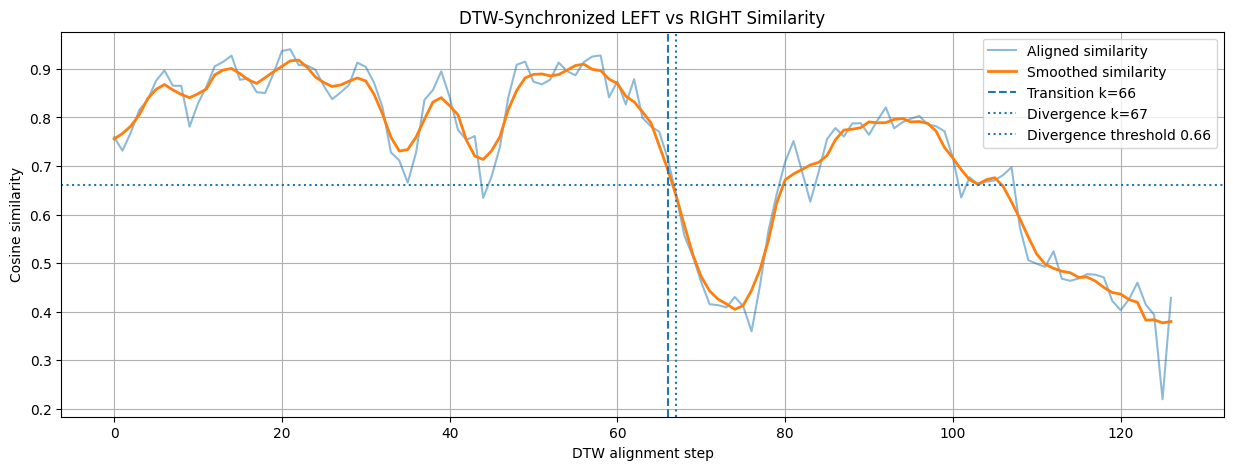

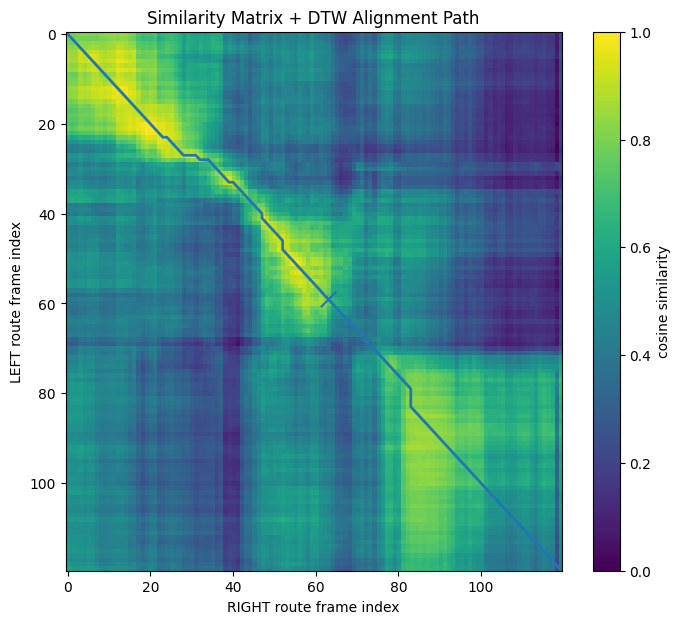


LEFT transition context: [56, 57, 58, 59, 60, 61, 62]
RIGHT transition context: [60, 61, 62, 63, 64, 65, 66]


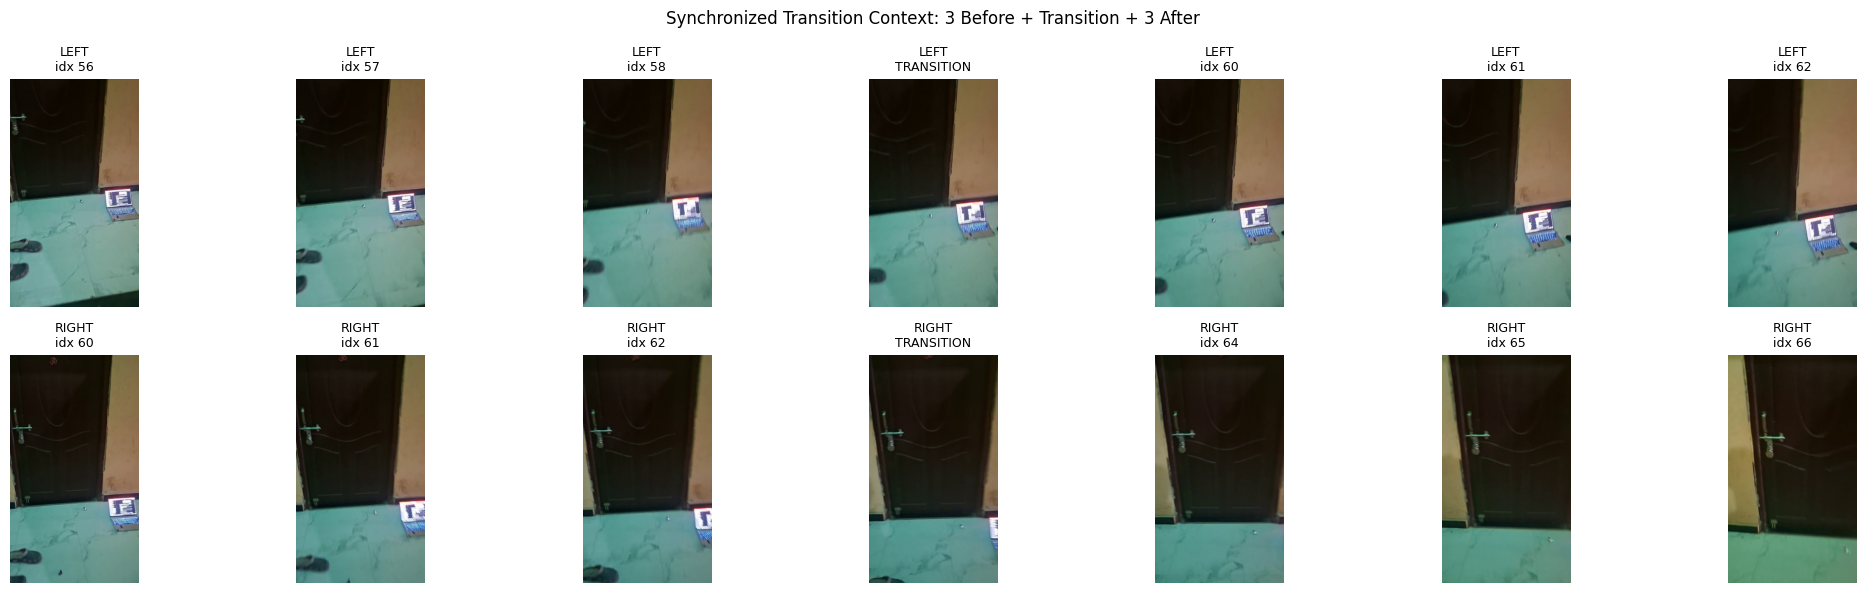

In [4]:
# ============================================================
# CELL 2: DTW-SYNCHRONIZED SHARED-PREFIX GRAPH BUILDER
# VXN-RAMNet Shared-Prefix Branch Graph Learning
#
# Fixes the old problem:
# left transition may happen at 10 sec
# right transition may happen at 7–8 sec
#
# This cell finds separate transition indices:
#   left_transition_index
#   right_transition_index
# ============================================================

import sys
import subprocess
from pathlib import Path
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tensorflow", "tensorflow")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("pillow", "PIL")
install_if_missing("matplotlib", "matplotlib")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

ROOT_DIR = Path(".")
FRAMES_DIR = ROOT_DIR / "vxn_branch_frames_dtw"

LEFT_FRAMES_DIR = FRAMES_DIR / "left_route"
RIGHT_FRAMES_DIR = FRAMES_DIR / "right_route"

GRAPH_MEMORY_NPZ = ROOT_DIR / "vxn_branch_graph_memory_dtw.npz"
GRAPH_METADATA_JSON = ROOT_DIR / "vxn_branch_graph_metadata_dtw.json"

MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 16
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

# DTW / divergence thresholds
COMMON_THRESHOLD = 0.76
DIVERGENCE_THRESHOLD = 0.66
STABLE_DROP_COUNT = 4
MIN_COMMON_ALIGNED_PAIRS = 8

TRANSITION_CONTEXT = 3

if not LEFT_FRAMES_DIR.exists() or not RIGHT_FRAMES_DIR.exists():
    raise FileNotFoundError("Frame folders missing. Run Cell 1 first.")


# ------------------------------------------------------------
# LOAD FRAMES
# ------------------------------------------------------------

def collect_frames(folder):
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

left_frames = collect_frames(LEFT_FRAMES_DIR)
right_frames = collect_frames(RIGHT_FRAMES_DIR)

print("LEFT frames:", len(left_frames))
print("RIGHT frames:", len(right_frames))


# ------------------------------------------------------------
# LOAD ENCODER
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder loaded and warmed up.")


# ------------------------------------------------------------
# ENCODING HELPERS
# ------------------------------------------------------------

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def build_batches(paths, batch_size=BATCH_SIZE):
    batch = []
    batch_paths = []

    for path in paths:
        batch.append(load_image_fast(path))
        batch_paths.append(str(path.as_posix()))

        if len(batch) == batch_size:
            batch_np = np.array(batch, dtype=np.float32)
            batch_np = preprocess_input(batch_np)
            yield batch_np, batch_paths
            batch = []
            batch_paths = []

    if batch:
        batch_np = np.array(batch, dtype=np.float32)
        batch_np = preprocess_input(batch_np)
        yield batch_np, batch_paths

def encode_frames(frame_paths, label):
    embeddings = []
    paths_text = []

    start = time.time()
    processed = 0

    for batch_np, batch_paths in build_batches(frame_paths):
        emb = encoder.predict(batch_np, verbose=0).astype(np.float32)
        emb = l2_normalize_matrix(emb)

        embeddings.append(emb)
        paths_text.extend(batch_paths)

        processed += len(batch_paths)
        print(f"{label}: encoded {processed}/{len(frame_paths)} frames")

    embeddings = np.vstack(embeddings).astype(np.float32)
    elapsed = time.time() - start

    print(f"{label}: encoding complete in {elapsed:.2f} sec")
    print(f"{label}: avg per frame {(elapsed / len(frame_paths)) * 1000:.2f} ms")

    return embeddings, paths_text


# ------------------------------------------------------------
# ENCODE LEFT AND RIGHT
# ------------------------------------------------------------

left_embeddings, left_paths_text = encode_frames(left_frames, "LEFT")
right_embeddings, right_paths_text = encode_frames(right_frames, "RIGHT")


# ------------------------------------------------------------
# DTW ALIGNMENT
# ------------------------------------------------------------

def dtw_align(similarity_matrix):
    """
    similarity_matrix shape:
        left_frames x right_frames

    Converts similarity to cost = 1 - similarity.
    Returns monotonic alignment path.
    """

    cost = 1.0 - similarity_matrix
    n, m = cost.shape

    dp = np.full((n, m), np.inf, dtype=np.float32)
    parent = np.empty((n, m, 2), dtype=np.int32)

    dp[0, 0] = cost[0, 0]
    parent[0, 0] = [-1, -1]

    for i in range(n):
        for j in range(m):
            if i == 0 and j == 0:
                continue

            candidates = []

            if i > 0:
                candidates.append((dp[i-1, j], i-1, j))
            if j > 0:
                candidates.append((dp[i, j-1], i, j-1))
            if i > 0 and j > 0:
                candidates.append((dp[i-1, j-1], i-1, j-1))

            best_prev, pi, pj = min(candidates, key=lambda x: x[0])
            dp[i, j] = cost[i, j] + best_prev
            parent[i, j] = [pi, pj]

    # Backtrack
    i, j = n - 1, m - 1
    path = []

    while i >= 0 and j >= 0:
        path.append((i, j))
        pi, pj = parent[i, j]
        if pi == -1 and pj == -1:
            break
        i, j = int(pi), int(pj)

    path.reverse()

    return path, dp[-1, -1]

similarity_matrix = left_embeddings @ right_embeddings.T

alignment_path, dtw_cost = dtw_align(similarity_matrix)

aligned_left_indices = np.array([p[0] for p in alignment_path], dtype=np.int32)
aligned_right_indices = np.array([p[1] for p in alignment_path], dtype=np.int32)
aligned_similarities = np.array([similarity_matrix[i, j] for i, j in alignment_path], dtype=np.float32)

print("\n✅ DTW synchronization complete.")
print("Alignment path length:", len(alignment_path))
print("DTW cost:", float(dtw_cost))


# ------------------------------------------------------------
# SMOOTH SIMILARITY
# ------------------------------------------------------------

def moving_average(x, window=5):
    if len(x) < window:
        return x
    pad = window // 2
    padded = np.pad(x, (pad, pad), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")

smoothed_sim = moving_average(aligned_similarities, window=5)


# ------------------------------------------------------------
# DETECT DIVERGENCE ON ALIGNED PATH
# ------------------------------------------------------------

def detect_dtw_divergence(aligned_sim, smoothed_sim):
    """
    Detects divergence on the synchronized alignment path.
    """

    for k in range(MIN_COMMON_ALIGNED_PAIRS, len(smoothed_sim) - STABLE_DROP_COUNT + 1):
        window = smoothed_sim[k:k + STABLE_DROP_COUNT]

        if np.all(window < DIVERGENCE_THRESHOLD):
            divergence_k = k
            transition_k = max(0, k - 1)

            return {
                "transition_k": int(transition_k),
                "divergence_k": int(divergence_k),
                "method": "dtw_stable_smoothed_drop",
                "window": window.tolist()
            }

    # Fallback: largest drop after minimum common region
    diffs = smoothed_sim[:-1] - smoothed_sim[1:]
    search_start = min(MIN_COMMON_ALIGNED_PAIRS, len(diffs) - 1)
    best_drop_k = int(np.argmax(diffs[search_start:]) + search_start)

    return {
        "transition_k": int(best_drop_k),
        "divergence_k": int(best_drop_k + 1),
        "method": "dtw_largest_drop_fallback",
        "largest_drop": float(diffs[best_drop_k])
    }

div_info = detect_dtw_divergence(aligned_similarities, smoothed_sim)

transition_k = div_info["transition_k"]
divergence_k = div_info["divergence_k"]

left_transition_index = int(aligned_left_indices[transition_k])
right_transition_index = int(aligned_right_indices[transition_k])

left_divergence_start = int(aligned_left_indices[divergence_k])
right_divergence_start = int(aligned_right_indices[divergence_k])

print("\n==============================")
print("DTW DIVERGENCE RESULT")
print("==============================")
print("Detection method:", div_info["method"])
print("Alignment transition k:", transition_k)
print("Alignment divergence k:", divergence_k)
print("LEFT transition index:", left_transition_index)
print("RIGHT transition index:", right_transition_index)
print("LEFT divergence start:", left_divergence_start)
print("RIGHT divergence start:", right_divergence_start)

if "window" in div_info:
    print("Stable drop window:", [round(x, 4) for x in div_info["window"]])
if "largest_drop" in div_info:
    print("Largest drop:", round(div_info["largest_drop"], 4))


# ------------------------------------------------------------
# BUILD GRAPH COMPONENTS
# ------------------------------------------------------------

# Common path uses matched pairs before divergence.
common_pairs = alignment_path[:transition_k + 1]

common_embeddings = []
common_left_frame_indices = []
common_right_frame_indices = []

for li, ri in common_pairs:
    avg = (left_embeddings[li] + right_embeddings[ri]) / 2.0
    common_embeddings.append(avg)
    common_left_frame_indices.append(li)
    common_right_frame_indices.append(ri)

common_embeddings = l2_normalize_matrix(np.vstack(common_embeddings)).astype(np.float32)

left_branch_embeddings = left_embeddings[left_divergence_start:]
right_branch_embeddings = right_embeddings[right_divergence_start:]

if len(left_branch_embeddings) == 0 or len(right_branch_embeddings) == 0:
    raise ValueError("Branch split failed. Try adjusting thresholds or increasing frames.")

print("\nGraph split summary:")
print("Common path pairs:", common_embeddings.shape[0])
print("LEFT branch frames:", left_branch_embeddings.shape[0])
print("RIGHT branch frames:", right_branch_embeddings.shape[0])


def centroid(x):
    c = np.mean(x, axis=0, keepdims=True)
    return l2_normalize_matrix(c)[0].astype(np.float32)

common_centroid = centroid(common_embeddings)
left_centroid = centroid(left_branch_embeddings)
right_centroid = centroid(right_branch_embeddings)


# ------------------------------------------------------------
# SAVE GRAPH MEMORY
# ------------------------------------------------------------

graph_embeddings = np.vstack([
    common_embeddings,
    left_branch_embeddings,
    right_branch_embeddings
]).astype(np.float32)

graph_labels = np.concatenate([
    np.full(len(common_embeddings), 0, dtype=np.int32),
    np.full(len(left_branch_embeddings), 1, dtype=np.int32),
    np.full(len(right_branch_embeddings), 2, dtype=np.int32)
])

graph_centroids = np.vstack([
    common_centroid,
    left_centroid,
    right_centroid
]).astype(np.float32)

component_names = np.array([
    "COMMON_PATH",
    "LEFT_BRANCH_HOME",
    "RIGHT_BRANCH_TUITION"
])

np.savez_compressed(
    GRAPH_MEMORY_NPZ,
    embeddings=graph_embeddings,
    labels=graph_labels,
    centroids=graph_centroids,
    component_names=component_names,
    left_embeddings=left_embeddings,
    right_embeddings=right_embeddings,
    similarity_matrix=similarity_matrix.astype(np.float32),
    aligned_left_indices=aligned_left_indices,
    aligned_right_indices=aligned_right_indices,
    aligned_similarities=aligned_similarities,
    smoothed_aligned_similarities=smoothed_sim.astype(np.float32),
    transition_k=np.array([transition_k], dtype=np.int32),
    divergence_k=np.array([divergence_k], dtype=np.int32),
    left_transition_index=np.array([left_transition_index], dtype=np.int32),
    right_transition_index=np.array([right_transition_index], dtype=np.int32),
    left_divergence_start=np.array([left_divergence_start], dtype=np.int32),
    right_divergence_start=np.array([right_divergence_start], dtype=np.int32),
    left_frame_paths=np.array(left_paths_text),
    right_frame_paths=np.array(right_paths_text)
)

metadata = {
    "system": "VXN-RAMNet",
    "architecture": "DTW-Synchronized Shared-Prefix Branch Graph Learning",
    "gps_used": False,
    "model_retraining_used": False,
    "model": "EfficientNetB0",
    "left_route_meaning": "College to Home, LEFT branch after divergence",
    "right_route_meaning": "College to Tuition, RIGHT branch after divergence",
    "thresholds": {
        "COMMON_THRESHOLD": COMMON_THRESHOLD,
        "DIVERGENCE_THRESHOLD": DIVERGENCE_THRESHOLD,
        "STABLE_DROP_COUNT": STABLE_DROP_COUNT,
        "MIN_COMMON_ALIGNED_PAIRS": MIN_COMMON_ALIGNED_PAIRS
    },
    "dtw_result": {
        "transition_k": int(transition_k),
        "divergence_k": int(divergence_k),
        "left_transition_index": int(left_transition_index),
        "right_transition_index": int(right_transition_index),
        "left_divergence_start": int(left_divergence_start),
        "right_divergence_start": int(right_divergence_start),
        "method": div_info["method"]
    },
    "graph": {
        "root": "College",
        "common_path": "College_to_Junction",
        "junction": "Junction_A",
        "transitions": {
            "LEFT": "Home",
            "RIGHT": "Tuition"
        }
    },
    "component_counts": {
        "COMMON_PATH": int(len(common_embeddings)),
        "LEFT_BRANCH_HOME": int(len(left_branch_embeddings)),
        "RIGHT_BRANCH_TUITION": int(len(right_branch_embeddings))
    },
    "created_at_unix": time.time()
}

with open(GRAPH_METADATA_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ DTW graph memory saved.")
print("Graph memory:", GRAPH_MEMORY_NPZ.resolve())
print("Metadata:", GRAPH_METADATA_JSON.resolve())


# ------------------------------------------------------------
# VISUALIZE DTW ALIGNMENT AND TRANSITION
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))
plt.plot(aligned_similarities, label="Aligned similarity", alpha=0.5)
plt.plot(smoothed_sim, label="Smoothed similarity", linewidth=2)
plt.axvline(transition_k, linestyle="--", label=f"Transition k={transition_k}")
plt.axvline(divergence_k, linestyle=":", label=f"Divergence k={divergence_k}")
plt.axhline(DIVERGENCE_THRESHOLD, linestyle=":", label=f"Divergence threshold {DIVERGENCE_THRESHOLD}")
plt.title("DTW-Synchronized LEFT vs RIGHT Similarity")
plt.xlabel("DTW alignment step")
plt.ylabel("Cosine similarity")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 7))
plt.imshow(similarity_matrix, aspect="auto")
plt.plot(aligned_right_indices, aligned_left_indices, linewidth=2)
plt.scatter([right_transition_index], [left_transition_index], marker="x", s=120)
plt.title("Similarity Matrix + DTW Alignment Path")
plt.xlabel("RIGHT route frame index")
plt.ylabel("LEFT route frame index")
plt.colorbar(label="cosine similarity")
plt.show()


# ------------------------------------------------------------
# DISPLAY TRANSITION CONTEXT
# ------------------------------------------------------------

def context_indices(center, total, context=3):
    start = max(0, center - context)
    end = min(total - 1, center + context)
    return list(range(start, end + 1))

left_context = context_indices(left_transition_index, len(left_frames), TRANSITION_CONTEXT)
right_context = context_indices(right_transition_index, len(right_frames), TRANSITION_CONTEXT)

print("\nLEFT transition context:", left_context)
print("RIGHT transition context:", right_context)

max_cols = max(len(left_context), len(right_context))
plt.figure(figsize=(max_cols * 3, 6))

for col in range(max_cols):
    if col < len(left_context):
        idx = left_context[col]
        img = Image.open(left_frames[idx]).convert("RGB")
        label = "TRANSITION" if idx == left_transition_index else f"idx {idx}"

        plt.subplot(2, max_cols, col + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"LEFT\n{label}", fontsize=9)

    if col < len(right_context):
        idx = right_context[col]
        img = Image.open(right_frames[idx]).convert("RGB")
        label = "TRANSITION" if idx == right_transition_index else f"idx {idx}"

        plt.subplot(2, max_cols, max_cols + col + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"RIGHT\n{label}", fontsize=9)

plt.suptitle("Synchronized Transition Context: 3 Before + Transition + 3 After")
plt.tight_layout()
plt.show()

✅ DTW graph memory loaded.
Components: ['COMMON_PATH', 'LEFT_BRANCH_HOME', 'RIGHT_BRANCH_TUITION']
LEFT transition index: 59
RIGHT transition index: 63
Query frames: 120

Loading EfficientNetB0 frozen encoder...
✅ Encoder loaded and warmed up.
QUERY: encoded 16/120 frames
QUERY: encoded 32/120 frames
QUERY: encoded 48/120 frames
QUERY: encoded 64/120 frames
QUERY: encoded 80/120 frames
QUERY: encoded 96/120 frames
QUERY: encoded 112/120 frames
QUERY: encoded 120/120 frames
QUERY: encoding complete in 3.83 sec
QUERY: avg per frame 31.96 ms

QUERY ROUTE SCORE REPORT


,Component,Average Score,Max Score,Min Score
0,COMMON_PATH,0.6482,0.8319,-0.1064
1,LEFT_BRANCH_HOME,0.8376,0.9228,0.6442
2,RIGHT_BRANCH_TUITION,0.7110,0.7807,0.5978



FINAL DTW BRANCH CLASSIFICATION
Prediction: LEFT_BRANCH_HOME
Reason: Strong LEFT branch evidence. Common path weakness ignored because branch is clearly LEFT.
Query common end index: 48
Query branch start index: 49
Common score: 0.6482
LEFT score: 0.8376
RIGHT score: 0.711
Branch gap: 0.1266

✅ Query classified as LEFT branch / Home route.


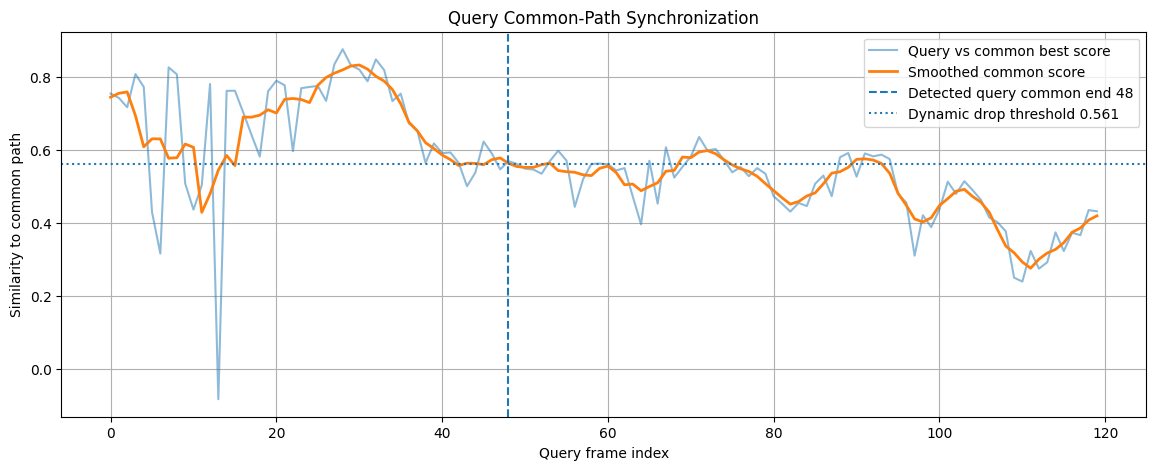


Query transition context indices:
[45, 46, 47, 48, 49, 50, 51]


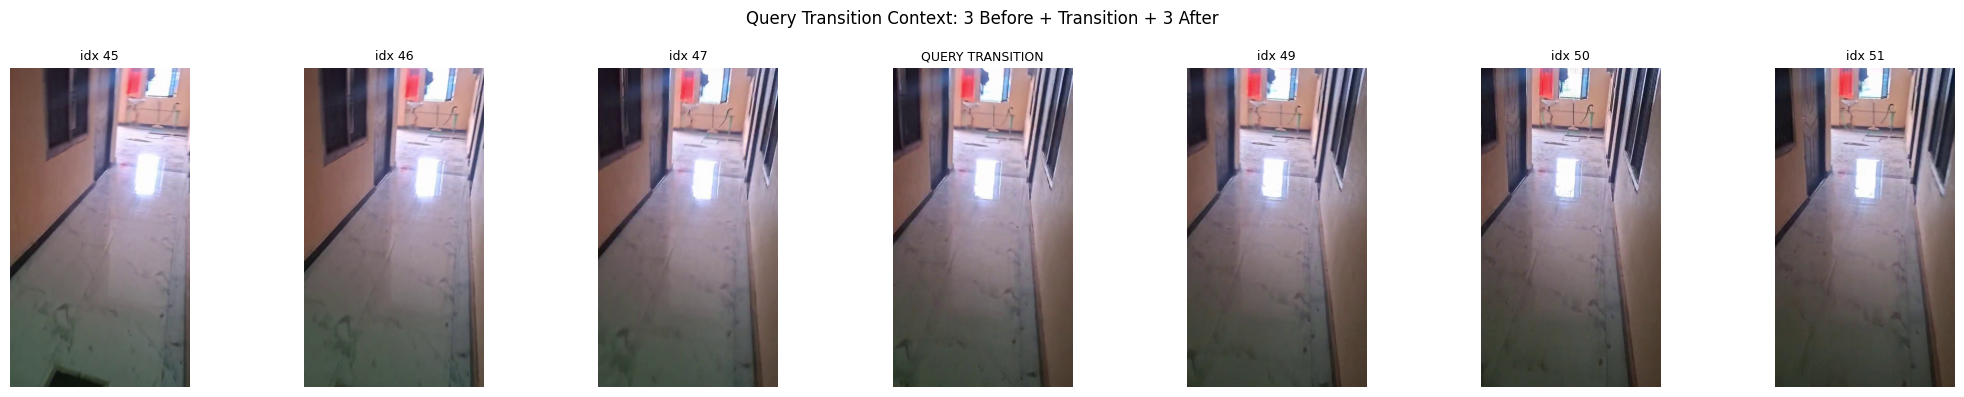

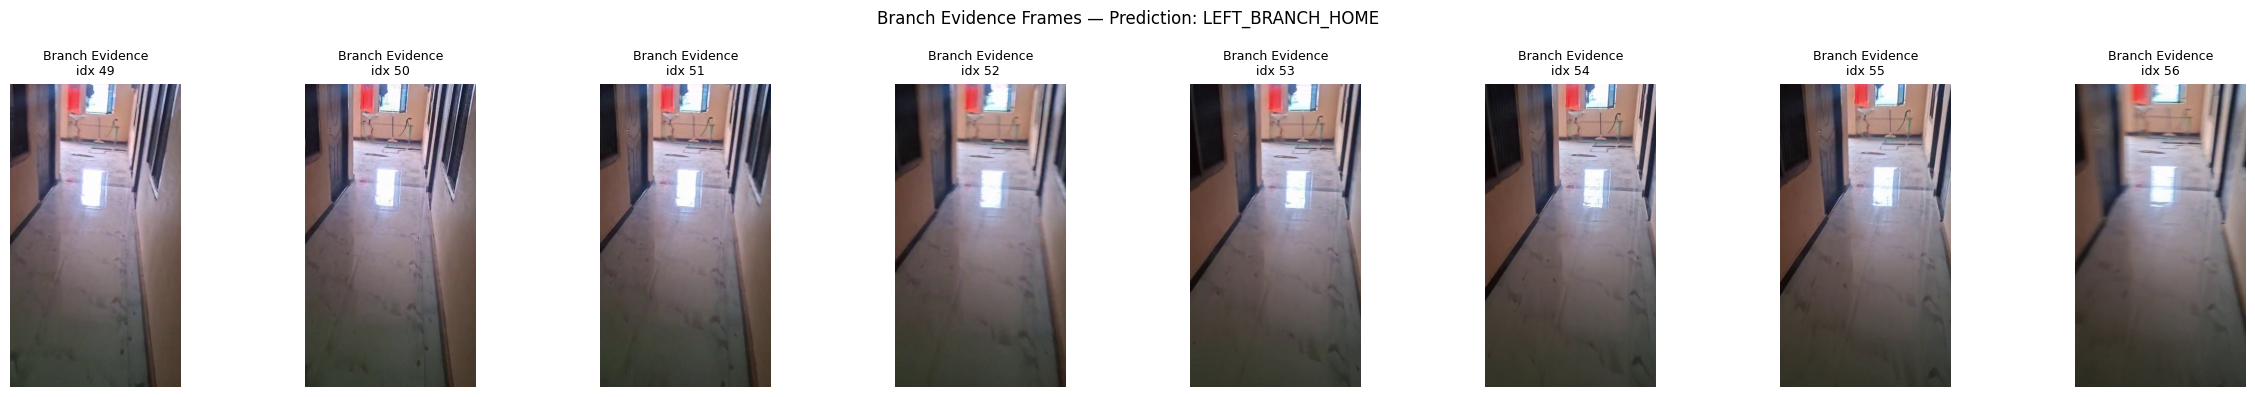


✅ Query classification report saved.
Report: C:\Users\progr\JupyterNotebook\VXN-RAM\vxn_branch_query_classification_report_dtw.json


In [5]:
# ============================================================
# CELL 3: DTW QUERY CLASSIFICATION
# VXN-RAMNet Branch Classifier With Dynamic Query Synchronization
#
# Output:
#   LEFT_BRANCH_HOME
#   RIGHT_BRANCH_TUITION
#   UNCERTAIN_BRANCH
#   UNKNOWN_BRANCH
# ============================================================

import sys
import subprocess
from pathlib import Path
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tensorflow", "tensorflow")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("pillow", "PIL")
install_if_missing("matplotlib", "matplotlib")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

ROOT_DIR = Path(".")
FRAMES_DIR = ROOT_DIR / "vxn_branch_frames_dtw"

QUERY_FRAMES_DIR = FRAMES_DIR / "query_route"

GRAPH_MEMORY_NPZ = ROOT_DIR / "vxn_branch_graph_memory_dtw.npz"
GRAPH_METADATA_JSON = ROOT_DIR / "vxn_branch_graph_metadata_dtw.json"
QUERY_REPORT_JSON = ROOT_DIR / "vxn_branch_query_classification_report_dtw.json"

MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 16
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

# Classification thresholds
MIN_BRANCH_SCORE = 0.66
MIN_BRANCH_GAP = 0.045

# If branch is very strong, do not reject only because common path is weak.
STRONG_BRANCH_SCORE = 0.78
STRONG_BRANCH_GAP = 0.08

COMMON_SOFT_MIN = 0.50

TRANSITION_CONTEXT = 3
BRANCH_WINDOW_LENGTH = 24

if not QUERY_FRAMES_DIR.exists():
    raise FileNotFoundError("Query frames missing. Run Cell 1 first.")

if not GRAPH_MEMORY_NPZ.exists():
    raise FileNotFoundError("Graph memory missing. Run Cell 2 first.")


# ------------------------------------------------------------
# LOAD GRAPH MEMORY
# ------------------------------------------------------------

memory = np.load(GRAPH_MEMORY_NPZ, allow_pickle=True)

graph_embeddings = memory["embeddings"].astype(np.float32)
graph_labels = memory["labels"].astype(np.int32)
graph_centroids = memory["centroids"].astype(np.float32)
component_names = memory["component_names"].tolist()

transition_k = int(memory["transition_k"][0])
divergence_k = int(memory["divergence_k"][0])
left_transition_index = int(memory["left_transition_index"][0])
right_transition_index = int(memory["right_transition_index"][0])

with open(GRAPH_METADATA_JSON, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("✅ DTW graph memory loaded.")
print("Components:", component_names)
print("LEFT transition index:", left_transition_index)
print("RIGHT transition index:", right_transition_index)


# ------------------------------------------------------------
# LOAD QUERY FRAMES
# ------------------------------------------------------------

query_frames = sorted([
    p for p in QUERY_FRAMES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

if len(query_frames) == 0:
    raise FileNotFoundError("No query frames found.")

print("Query frames:", len(query_frames))


# ------------------------------------------------------------
# LOAD ENCODER
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder loaded and warmed up.")


# ------------------------------------------------------------
# ENCODING HELPERS
# ------------------------------------------------------------

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def build_batches(paths, batch_size=BATCH_SIZE):
    batch = []
    batch_paths = []

    for path in paths:
        batch.append(load_image_fast(path))
        batch_paths.append(str(path.as_posix()))

        if len(batch) == batch_size:
            batch_np = np.array(batch, dtype=np.float32)
            batch_np = preprocess_input(batch_np)
            yield batch_np, batch_paths
            batch = []
            batch_paths = []

    if batch:
        batch_np = np.array(batch, dtype=np.float32)
        batch_np = preprocess_input(batch_np)
        yield batch_np, batch_paths

def encode_frames(frame_paths, label):
    embeddings = []
    paths_text = []

    start = time.time()
    processed = 0

    for batch_np, batch_paths in build_batches(frame_paths):
        emb = encoder.predict(batch_np, verbose=0).astype(np.float32)
        emb = l2_normalize_matrix(emb)

        embeddings.append(emb)
        paths_text.extend(batch_paths)

        processed += len(batch_paths)
        print(f"{label}: encoded {processed}/{len(frame_paths)} frames")

    embeddings = np.vstack(embeddings).astype(np.float32)
    elapsed = time.time() - start

    print(f"{label}: encoding complete in {elapsed:.2f} sec")
    print(f"{label}: avg per frame {(elapsed / len(frame_paths)) * 1000:.2f} ms")

    return embeddings, paths_text


# ------------------------------------------------------------
# ENCODE QUERY
# ------------------------------------------------------------

query_embeddings, query_paths_text = encode_frames(query_frames, "QUERY")


# ------------------------------------------------------------
# SPLIT COMPONENTS
# ------------------------------------------------------------

COMMON_LABEL = 0
LEFT_LABEL = 1
RIGHT_LABEL = 2

common_memory = graph_embeddings[graph_labels == COMMON_LABEL]
left_memory = graph_embeddings[graph_labels == LEFT_LABEL]
right_memory = graph_embeddings[graph_labels == RIGHT_LABEL]

common_centroid = graph_centroids[COMMON_LABEL]
left_centroid = graph_centroids[LEFT_LABEL]
right_centroid = graph_centroids[RIGHT_LABEL]


# ------------------------------------------------------------
# SCORING FUNCTIONS
# ------------------------------------------------------------

def component_score(test_embeddings, memory_embeddings, centroid_embedding):
    scores = test_embeddings @ memory_embeddings.T

    best_per_frame = np.max(scores, axis=1)

    top3_per_frame = []
    for row in scores:
        sorted_row = np.sort(row)[::-1]
        top3_per_frame.append(np.mean(sorted_row[:min(3, len(sorted_row))]))

    top3_per_frame = np.array(top3_per_frame)

    centroid_scores = test_embeddings @ centroid_embedding

    final_per_frame = (
        0.50 * best_per_frame +
        0.30 * top3_per_frame +
        0.20 * centroid_scores
    )

    return {
        "average_score": float(np.mean(final_per_frame)),
        "max_score": float(np.max(final_per_frame)),
        "min_score": float(np.min(final_per_frame)),
        "per_frame_scores": final_per_frame
    }

def find_query_common_end(query_embeddings, common_memory):
    """
    Finds where the common path likely ends in the query video.
    It does not assume same timing.
    """

    # Query frame vs common memory
    sim = query_embeddings @ common_memory.T
    best_common_per_query = np.max(sim, axis=1)

    # Smooth scores
    def moving_average(x, window=5):
        if len(x) < window:
            return x
        pad = window // 2
        padded = np.pad(x, (pad, pad), mode="edge")
        return np.convolve(padded, np.ones(window) / window, mode="valid")

    smooth = moving_average(best_common_per_query, window=5)

    # Common path usually appears at start, then drops.
    # Find last strong common frame before a stable drop.
    drop_threshold = max(COMMON_SOFT_MIN, float(np.percentile(smooth, 55)))

    stable_drop = 4
    min_prefix = 5

    for i in range(min_prefix, len(smooth) - stable_drop + 1):
        window = smooth[i:i + stable_drop]
        if np.all(window < drop_threshold):
            return max(0, i - 1), best_common_per_query, smooth, drop_threshold

    # Fallback: use peak zone ending
    peak_idx = int(np.argmax(smooth))
    return max(peak_idx, min_prefix), best_common_per_query, smooth, drop_threshold

def safe_indices(start, length, total):
    start = max(0, min(start, total - 1))
    end = min(total, start + length)
    return list(range(start, end))


# ------------------------------------------------------------
# DYNAMIC QUERY COMMON END
# ------------------------------------------------------------

query_common_end, query_common_raw, query_common_smooth, common_dynamic_threshold = find_query_common_end(
    query_embeddings,
    common_memory
)

query_branch_start = min(query_common_end + 1, len(query_embeddings) - 1)

branch_indices = safe_indices(
    query_branch_start,
    BRANCH_WINDOW_LENGTH,
    len(query_embeddings)
)

query_common_embeddings = query_embeddings[:query_common_end + 1]
query_branch_embeddings = query_embeddings[branch_indices]

common_score = component_score(
    query_common_embeddings,
    common_memory,
    common_centroid
)

left_score = component_score(
    query_branch_embeddings,
    left_memory,
    left_centroid
)

right_score = component_score(
    query_branch_embeddings,
    right_memory,
    right_centroid
)

left_avg = left_score["average_score"]
right_avg = right_score["average_score"]
branch_gap = abs(left_avg - right_avg)


# ------------------------------------------------------------
# FINAL DECISION LOGIC
# ------------------------------------------------------------

if max(left_avg, right_avg) >= STRONG_BRANCH_SCORE and branch_gap >= STRONG_BRANCH_GAP:
    if left_avg > right_avg:
        prediction = "LEFT_BRANCH_HOME"
        reason = "Strong LEFT branch evidence. Common path weakness ignored because branch is clearly LEFT."
    else:
        prediction = "RIGHT_BRANCH_TUITION"
        reason = "Strong RIGHT branch evidence. Common path weakness ignored because branch is clearly RIGHT."

elif common_score["average_score"] < COMMON_SOFT_MIN and max(left_avg, right_avg) < STRONG_BRANCH_SCORE:
    prediction = "UNKNOWN_OR_WEAK_COMMON_PATH"
    reason = "Common path is weak and branch evidence is not strong enough."

elif max(left_avg, right_avg) < MIN_BRANCH_SCORE:
    prediction = "UNKNOWN_BRANCH"
    reason = "Neither LEFT nor RIGHT branch is strong."

elif branch_gap < MIN_BRANCH_GAP:
    prediction = "UNCERTAIN_BRANCH"
    reason = "LEFT and RIGHT branch scores are too close."

elif left_avg > right_avg:
    prediction = "LEFT_BRANCH_HOME"
    reason = "Query branch is closer to LEFT/Home branch."

else:
    prediction = "RIGHT_BRANCH_TUITION"
    reason = "Query branch is closer to RIGHT/Tuition branch."


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

score_report = pd.DataFrame([
    {
        "Component": "COMMON_PATH",
        "Average Score": round(common_score["average_score"], 4),
        "Max Score": round(common_score["max_score"], 4),
        "Min Score": round(common_score["min_score"], 4)
    },
    {
        "Component": "LEFT_BRANCH_HOME",
        "Average Score": round(left_avg, 4),
        "Max Score": round(left_score["max_score"], 4),
        "Min Score": round(left_score["min_score"], 4)
    },
    {
        "Component": "RIGHT_BRANCH_TUITION",
        "Average Score": round(right_avg, 4),
        "Max Score": round(right_score["max_score"], 4),
        "Min Score": round(right_score["min_score"], 4)
    }
])

print("\n==============================")
print("QUERY ROUTE SCORE REPORT")
print("==============================")
display(score_report)

print("\n==============================")
print("FINAL DTW BRANCH CLASSIFICATION")
print("==============================")
print("Prediction:", prediction)
print("Reason:", reason)
print("Query common end index:", query_common_end)
print("Query branch start index:", query_branch_start)
print("Common score:", round(common_score["average_score"], 4))
print("LEFT score:", round(left_avg, 4))
print("RIGHT score:", round(right_avg, 4))
print("Branch gap:", round(branch_gap, 4))

if prediction == "LEFT_BRANCH_HOME":
    print("\n✅ Query classified as LEFT branch / Home route.")
elif prediction == "RIGHT_BRANCH_TUITION":
    print("\n✅ Query classified as RIGHT branch / Tuition route.")
elif prediction == "UNCERTAIN_BRANCH":
    print("\n⚠️ Query is uncertain. Use more frames or tune thresholds.")
else:
    print("\n⚠️ Query is unknown or weak.")


# ------------------------------------------------------------
# VISUALIZE QUERY COMMON MATCH CURVE
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(query_common_raw, label="Query vs common best score", alpha=0.5)
plt.plot(query_common_smooth, label="Smoothed common score", linewidth=2)
plt.axvline(query_common_end, linestyle="--", label=f"Detected query common end {query_common_end}")
plt.axhline(common_dynamic_threshold, linestyle=":", label=f"Dynamic drop threshold {common_dynamic_threshold:.3f}")
plt.title("Query Common-Path Synchronization")
plt.xlabel("Query frame index")
plt.ylabel("Similarity to common path")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# DISPLAY QUERY TRANSITION CONTEXT
# ------------------------------------------------------------

def context_indices(center, total, context=3):
    start = max(0, center - context)
    end = min(total - 1, center + context)
    return list(range(start, end + 1))

query_context = context_indices(
    query_common_end,
    len(query_frames),
    TRANSITION_CONTEXT
)

print("\nQuery transition context indices:")
print(query_context)

plt.figure(figsize=(len(query_context) * 3, 4))

for col, idx in enumerate(query_context, start=1):
    img = Image.open(query_frames[idx]).convert("RGB")
    label = "QUERY TRANSITION" if idx == query_common_end else f"idx {idx}"

    plt.subplot(1, len(query_context), col)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label, fontsize=9)

plt.suptitle("Query Transition Context: 3 Before + Transition + 3 After")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# DISPLAY BRANCH EVIDENCE FRAMES
# ------------------------------------------------------------

show_count = min(8, len(branch_indices))

plt.figure(figsize=(show_count * 3, 4))

for i, idx in enumerate(branch_indices[:show_count], start=1):
    img = Image.open(query_frames[idx]).convert("RGB")

    plt.subplot(1, show_count, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Branch Evidence\nidx {idx}", fontsize=9)

plt.suptitle(f"Branch Evidence Frames — Prediction: {prediction}")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

query_report = {
    "system": "VXN-RAMNet",
    "architecture": "DTW-Synchronized Shared-Prefix Branch Classifier",
    "prediction": prediction,
    "reason": reason,
    "query_common_end": int(query_common_end),
    "query_branch_start": int(query_branch_start),
    "scores": {
        "common_score": float(common_score["average_score"]),
        "left_branch_score": float(left_avg),
        "right_branch_score": float(right_avg),
        "branch_gap": float(branch_gap)
    },
    "thresholds": {
        "COMMON_SOFT_MIN": COMMON_SOFT_MIN,
        "MIN_BRANCH_SCORE": MIN_BRANCH_SCORE,
        "MIN_BRANCH_GAP": MIN_BRANCH_GAP,
        "STRONG_BRANCH_SCORE": STRONG_BRANCH_SCORE,
        "STRONG_BRANCH_GAP": STRONG_BRANCH_GAP
    },
    "graph": metadata["graph"],
    "created_at_unix": time.time()
}

with open(QUERY_REPORT_JSON, "w", encoding="utf-8") as f:
    json.dump(query_report, f, indent=2)

print("\n✅ Query classification report saved.")
print("Report:", QUERY_REPORT_JSON.resolve())